# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [5]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [6]:
filename="SUSY-small.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [7]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [8]:
#I am only using 400k rows as I only have 500k rows, because I am using a compressed version of the data set
#since the full version kept crashing, and not loading at all
N_Train=400000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [9]:
Fisher.fit(X_Train,y_Train)

LinearDiscriminantAnalysis()

In [10]:
#Testing if it works
print(Fisher.coef_)

[[ 1.14649558e+00  3.60588252e-03  8.53782896e-04  4.97600621e-01
   1.02778753e-03 -2.87641024e-05  8.34316406e-01  3.18073864e-04
   6.36531522e-02  1.28826259e-01 -1.35774986e-01  6.26533124e-02
  -1.03405092e+00 -1.60293019e-01 -9.06444612e-01  8.38592904e-01
  -3.93591610e-02  2.49888895e+00]]


We can plot the output, comparing signal and background:

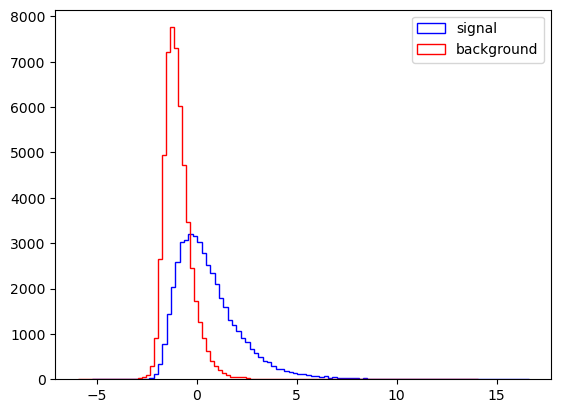

In [11]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

In [9]:
#Trying an error I was having where it said Found array with 0 sample(s) (shape=(0, 18)) while a minimum of 1 is required by LinearDiscriminantAnalysis. 
print("Test_sig shape:", Test_sig.shape)
print("Test_bkg shape:", Test_bkg.shape)

Test_sig shape: (0, 19)
Test_bkg shape: (0, 19)


In [4]:
#I only 500k rows
print("Total rows in df:", len(df))

Total rows in df: 500000


#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

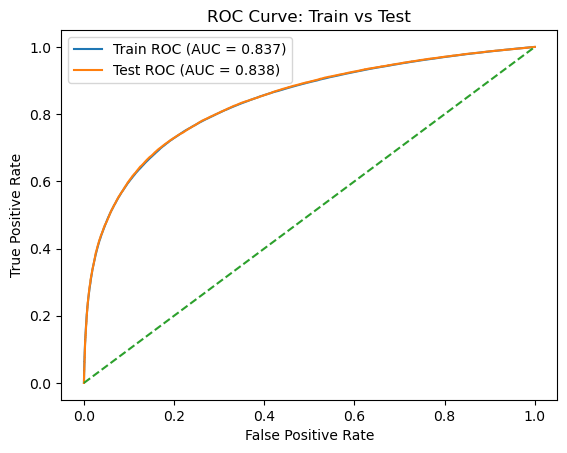

In [19]:
from sklearn.metrics import roc_curve, auc

# Get decision scores, used to build the ROC curve
y_train_scores = Fisher.decision_function(X_Train)
y_test_scores  = Fisher.decision_function(X_Test)

# Compute ROC curve for training data
fpr_train, tpr_train, _ = roc_curve(y_Train, y_train_scores)
auc_train = auc(fpr_train, tpr_train)

# Compute ROC curve for testing data
fpr_test, tpr_test, _ = roc_curve(y_Test, y_test_scores)
auc_test = auc(fpr_test, tpr_test)

# Plot both ROC curves on the same graph
plt.figure()

plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {auc_train:.3f})")
plt.plot(fpr_test,  tpr_test,  label=f"Test ROC (AUC = {auc_test:.3f})")

# Diagonal line represents random guessing
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Train vs Test")
plt.legend()
plt.show()

No, it is not that biased compared to random guessing. 

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

In [14]:
# Split variables into groups
RawVars = VarNames[1:10]     # raw features
FeatVars = VarNames[10:]     # engineered features
AllVars = VarNames[1:]       # all features combined

In [15]:
# Created separate Fisher models for each feature set
Fisher_raw = DA.LinearDiscriminantAnalysis()
Fisher_feat = DA.LinearDiscriminantAnalysis()
Fisher_all = DA.LinearDiscriminantAnalysis()

# Train models on different feature sets
Fisher_raw.fit(Train_Sample[RawVars], y_Train)
Fisher_feat.fit(Train_Sample[FeatVars], y_Train)
Fisher_all.fit(Train_Sample[AllVars], y_Train)

LinearDiscriminantAnalysis()

In [17]:
# Decision scores for test data
score_raw = Fisher_raw.decision_function(Test_Sample[RawVars])
score_feat = Fisher_feat.decision_function(Test_Sample[FeatVars])
score_all = Fisher_all.decision_function(Test_Sample[AllVars])

# Compute ROC curves
fpr_raw, tpr_raw, _ = roc_curve(y_Test, score_raw)
fpr_feat, tpr_feat, _ = roc_curve(y_Test, score_feat)
fpr_all, tpr_all, _ = roc_curve(y_Test, score_all)

# Compute AUC values
auc_raw = auc(fpr_raw, tpr_raw)
auc_feat = auc(fpr_feat, tpr_feat)
auc_all = auc(fpr_all, tpr_all)

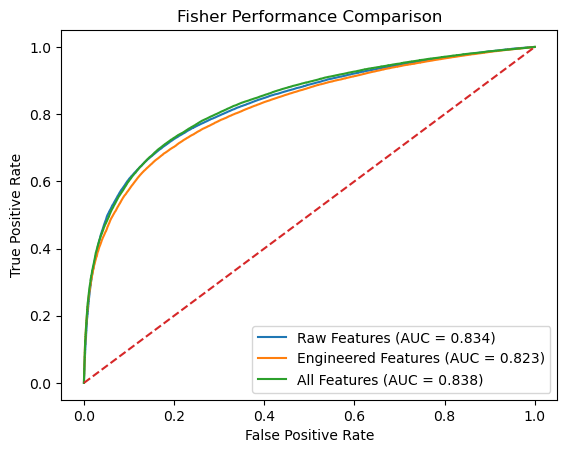

In [18]:
plt.figure()

# Plot ROC curves for all models
plt.plot(fpr_raw, tpr_raw, label=f"Raw Features (AUC = {auc_raw:.3f})")
plt.plot(fpr_feat, tpr_feat, label=f"Engineered Features (AUC = {auc_feat:.3f})")
plt.plot(fpr_all, tpr_all, label=f"All Features (AUC = {auc_all:.3f})")

# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Fisher Performance Comparison")
plt.legend()
plt.show()

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

In [20]:
#Part a

import sklearn.linear_model as LM
import sklearn.ensemble as EN
import sklearn.neighbors as KN

# 1. Logistic Regression
log_model = LM.LogisticRegression(max_iter=1000)

# 2. Random Forest
rf_model = EN.RandomForestClassifier(n_estimators=100, random_state=42)

# 3. K-Nearest Neighbors
knn_model = KN.KNeighborsClassifier(n_neighbors=5)

In [22]:
#Part b

def compare_classifier(model, X_train, y_train, X_test, y_test, label):
    # Train the classifier
    model.fit(X_train, y_train)

    # Get decision scores
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X_test)
    else:
        scores = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, scores)

    # Compute AUC
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.3f})")

    return roc_auc

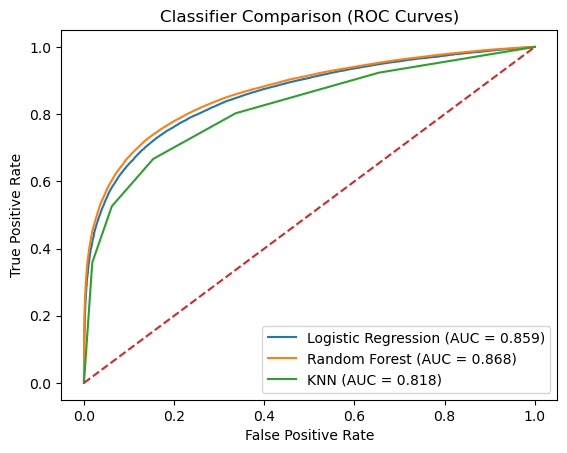

In [23]:
#Part b

plt.figure()

auc_log = compare_classifier(log_model, X_Train, y_Train, X_Test, y_Test, "Logistic Regression")
auc_rf  = compare_classifier(rf_model,  X_Train, y_Train, X_Test, y_Test, "Random Forest")
auc_knn = compare_classifier(knn_model, X_Train, y_Train, X_Test, y_Test, "KNN")

# Baseline line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Classifier Comparison (ROC Curves)")
plt.legend()
plt.show()

The Random Forest is the best model according to the roc curve

In [28]:
#Part c

def significance(NS, NB):
    return NS / np.sqrt(NS + NB)

# Scenarios
scenarios = [
    (10, 100),
    (100, 1000),
    (1000, 10000),
    (10000, 100000)]

# Compute and print results
for NS, NB in scenarios:
    sigma = significance(NS, NB)
    print(f"NS={NS}, NB={NB} → Significance = {sigma:.3f}")

NS=10, NB=100 → Significance = 0.953
NS=100, NB=1000 → Significance = 3.015
NS=1000, NB=10000 → Significance = 9.535
NS=10000, NB=100000 → Significance = 30.151


### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

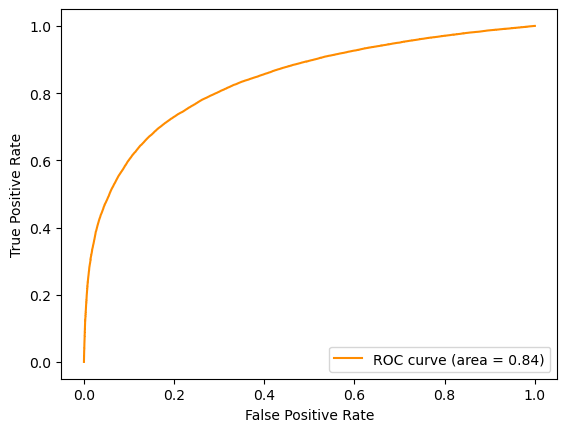

In [29]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [30]:
from sklearn.metrics import (
    precision_score, recall_score,
    f1_score, accuracy_score)

In [31]:
# Get prediction scores from Random Forest
if hasattr(rf_model, "decision_function"):
    scores = rf_model.decision_function(X_Test)
else:
    scores = rf_model.predict_proba(X_Test)[:, 1]

In [32]:
def evaluate_model(y_true, scores, threshold=0.5):
    
    # Convert scores into binary predictions
    y_pred = (scores > threshold).astype(int)

    # Compute metrics
    fpr, tpr, _ = roc_curve(y_true, scores)
    roc_auc = auc(fpr, tpr)

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)

    return fpr, tpr, roc_auc, precision, recall, f1, accuracy

In [33]:
def significance(NS, NB):
    return NS / np.sqrt(NS + NB)

def compute_max_significance(y_true, scores):
    thresholds = np.linspace(min(scores), max(scores), 100)

    best_sigma = 0

    for t in thresholds:
        y_pred = (scores > t).astype(int)

        NS = np.sum((y_pred == 1) & (y_true == 1))
        NB = np.sum((y_pred == 1) & (y_true == 0))

        if (NS + NB) == 0:
            continue

        sigma = significance(NS, NB)

        if sigma > best_sigma:
            best_sigma = sigma

    return best_sigma

In [34]:
# Store results
results = []

scenarios = [(10, 100),
    (100, 1000),
    (1000, 10000),
    (10000, 100000)]

for NS, NB in scenarios:
    # Scale dataset expectations
    sigma = significance(NS, NB)

    # Use full test set metrics
    fpr, tpr, roc_auc, precision, recall, f1, accuracy = evaluate_model(y_Test, scores)

    results.append({
        "NS": NS,
        "NB": NB,
        "TPR": tpr.mean(),   
        "FPR": fpr.mean(),   
        "AUC": roc_auc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Accuracy": accuracy,
        "Max Significance": sigma})

In [35]:
df_results = pd.DataFrame(results)

# Display table
print(df_results)

      NS      NB      TPR       FPR       AUC  Precision    Recall  F1 Score  \
0     10     100  0.68474  0.274267  0.868442   0.825305  0.711634  0.764266   
1    100    1000  0.68474  0.274267  0.868442   0.825305  0.711634  0.764266   
2   1000   10000  0.68474  0.274267  0.868442   0.825305  0.711634  0.764266   
3  10000  100000  0.68474  0.274267  0.868442   0.825305  0.711634  0.764266   

   Accuracy  Max Significance  
0   0.79824          0.953463  
1   0.79824          3.015113  
2   0.79824          9.534626  
3   0.79824         30.151134  
